In [2]:
import numpy as np
import pandas as pd


In [7]:
master_df = pd.read_csv("../data/processed/energy_master.csv")


In [8]:
print(master_df.shape)

(21394429, 7)


In [9]:
master_df["meter"].nunique()

84

In [10]:
master_df["city"].value_counts()

city
Bareilly    13495635
Mathura      7898794
Name: count, dtype: int64

In [11]:
print(master_df["x_Timestamp"].min())
print(master_df["x_Timestamp"].max())

2019-05-01 00:00:00
2021-10-31 23:57:00


In [12]:
master_df.describe()

,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz)
count,2.139443e+07,2.139443e+07,2.139443e+07,2.139443e+07
mean,1.707523e-02,2.230848e+02,1.616208e+00,4.590684e+01
std,2.477232e-02,6.875111e+01,2.196134e+00,1.371324e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e-03,2.302200e+02,2.700000e-01,4.996000e+01
50%,9.000000e-03,2.437000e+02,9.300000e-01,5.000000e+01
75%,2.000000e-02,2.535300e+02,2.000000e+00,5.004000e+01
max,3.000000e-01,6.547300e+02,1.260500e+02,5.703300e+02


In [13]:
master_df["x_Timestamp"] = pd.to_datetime(
    master_df["x_Timestamp"]
)

In [14]:
master_df["hour"] = master_df["x_Timestamp"].dt.hour

master_df["day"] = master_df["x_Timestamp"].dt.day

master_df["month"] = master_df["x_Timestamp"].dt.month

master_df["weekday"] = master_df["x_Timestamp"].dt.dayofweek

master_df["year"] = master_df["x_Timestamp"].dt.year

In [15]:
hourly_usage = (
    master_df
    .groupby("hour")["t_kWh"]
    .mean()
)

print(hourly_usage)

hour
0     0.020637
1     0.019584
2     0.018662
3     0.017662
4     0.016578
5     0.015333
6     0.013213
7     0.013578
8     0.015467
9     0.016098
10    0.015665
11    0.015581
12    0.015677
13    0.016187
14    0.017084
15    0.016572
16    0.015816
17    0.014925
18    0.015022
19    0.016910
20    0.019245
21    0.020875
22    0.021735
23    0.021708
Name: t_kWh, dtype: float64


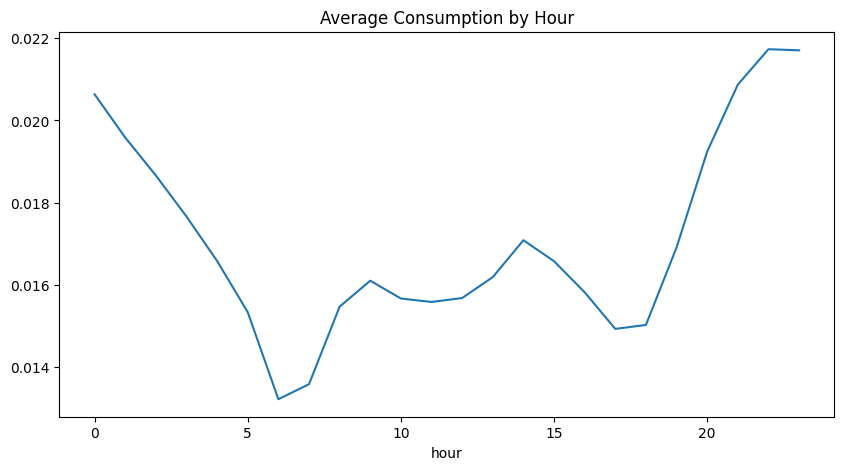

In [16]:
import matplotlib.pyplot as plt

hourly_usage.plot(figsize=(10,5))

plt.title("Average Consumption by Hour")
plt.show()

In [17]:
daily_usage = (
    master_df
    .set_index("x_Timestamp")
    .resample("D")["t_kWh"]
    .sum()
)

<Axes: xlabel='x_Timestamp'>

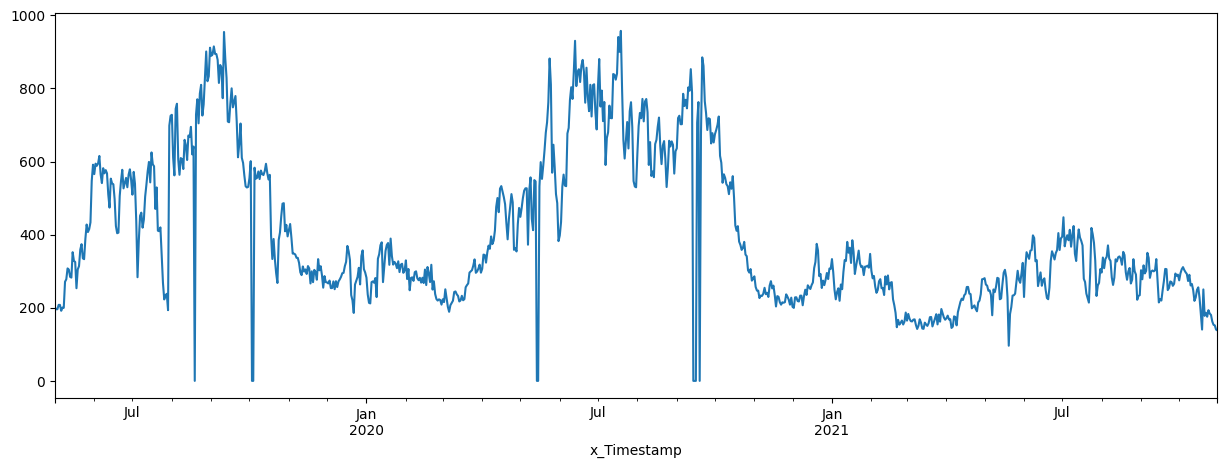

In [18]:
daily_usage.plot(figsize=(15,5))

In [19]:
master_df.groupby("city")["t_kWh"].mean()

city
Bareilly    0.017101
Mathura     0.017031
Name: t_kWh, dtype: float64

In [20]:
master_df.groupby(
    ["city","hour"]
)["t_kWh"].mean()

city      hour
Bareilly  0       0.019597
          1       0.018446
          2       0.017385
          3       0.016398
          4       0.015323
          5       0.014287
          6       0.012749
          7       0.013617
          8       0.016390
          9       0.016773
          10      0.016337
          11      0.016187
          12      0.016186
          13      0.016790
          14      0.017879
          15      0.017140
          16      0.016746
          17      0.016156
          18      0.016275
          19      0.017841
          20      0.019631
          21      0.020555
          22      0.020908
          23      0.020829
Mathura   0       0.022417
          1       0.021530
          2       0.020845
          3       0.019819
          4       0.018723
          5       0.017119
          6       0.014004
          7       0.013512
          8       0.013892
          9       0.014947
          10      0.014517
          11      0.014545
          12 

In [22]:
hourly_df = (
    master_df
    .set_index("x_Timestamp")
    .groupby(["city","meter"])
    .resample("h")["t_kWh"]
    .sum()
    .reset_index()
)

In [23]:
print(master_df.shape)

print(master_df["meter"].nunique())

print(master_df["city"].value_counts())

print(master_df["x_Timestamp"].min())
print(master_df["x_Timestamp"].max())

master_df.describe()

(21394429, 12)
84
city
Bareilly    13495635
Mathura      7898794
Name: count, dtype: int64
2019-05-01 00:00:00
2021-10-31 23:57:00


,x_Timestamp,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz),hour,day,month,weekday,year
count,21394429,2.139443e+07,2.139443e+07,2.139443e+07,2.139443e+07,2.139443e+07,2.139443e+07,2.139443e+07,2.139443e+07,2.139443e+07
mean,2020-06-08 18:00:59.190057472,1.707523e-02,2.230848e+02,1.616208e+00,4.590684e+01,1.149995e+01,1.577330e+01,6.881521e+00,3.009458e+00,2.019906e+03
min,2019-05-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,2.019000e+03
25%,2019-11-24 12:21:00,2.000000e-03,2.302200e+02,2.700000e-01,4.996000e+01,6.000000e+00,8.000000e+00,4.000000e+00,1.000000e+00,2.019000e+03
50%,2020-05-22 16:24:00,9.000000e-03,2.437000e+02,9.300000e-01,5.000000e+01,1.100000e+01,1.600000e+01,7.000000e+00,3.000000e+00,2.020000e+03
75%,2020-11-30 13:57:00,2.000000e-02,2.535300e+02,2.000000e+00,5.004000e+01,1.700000e+01,2.300000e+01,1.000000e+01,5.000000e+00,2.020000e+03
max,2021-10-31 23:57:00,3.000000e-01,6.547300e+02,1.260500e+02,5.703300e+02,2.300000e+01,3.100000e+01,1.200000e+01,6.000000e+00,2.021000e+03
std,NaN,2.477232e-02,6.875111e+01,2.196134e+00,1.371324e+01,6.921694e+00,8.789119e+00,3.398485e+00,2.002219e+00,7.111245e-01
